# Sub-Agent 를 활용한 `컨텍스트 격리(Context Isolation)` & `작업 위임(Task Delegation)`

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

---

## Context Isolation: Sub-agent 활용

**Context Isolation**은 복잡한 시스템에서 컨텍스트 충돌 및 오염을  
방지하기 위해 각 작업을 독립된 **Sub-agent**에게 위임하는 전략입니다.

*   **필요성**: 단일 컨텍스트 윈도우 내 다목적 혼재로 인한 성능 저하 방지
*   **해결책**: 특화된 Sub-agent가 격리된 환경에서 작업 수행
*   **참고**: [LangChain Context Engineering](https://blog.langchain.com/context-engineering-for-agents/), [Anthropic Multi-agent System](https://www.anthropic.com/engineering/multi-agent-research-system)

---

### Sub-agent 위임 구조

*   **구조**: `subagent_type`을 Key로 하는 **Agent Registry** 활용
*   **동작**:
    1.  Main Agent가 `task(description, subagent_type)` 호출
    2.  Sub-agent가 분리된 컨텍스트에서 작업 수행
    3.  결과를 `ToolMessage`로 반환
*   **장점**: 역할 분리, 시스템 안정성 및 확장성 향상

---

## Sub-agent 정의

`TypedDict`를 사용하여 Sub-agent의 구성 요소(이름, 설명, 프롬프트, 도구)를 정의하고 관리합니다.

```python
class SubAgent(TypedDict):
    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]
```

*   **구성**:
    *   `name`: 에이전트 식별자(`main agent`에서 호출 시 사용)
    *   `description`: 역할 설명(`main agent`에서 호출 시 사용)
    *   `prompt`: 전용 시스템 프롬프트(`sub-agent` 작업 지시)
    *   `tools`: 사용 가능한 도구 목록(`sub-agent` 작업 도구)
*   **등록**: 리스트 형태로 관리하며 시스템에 일괄 등록

In [4]:
# SubAgent TypedDict import
from dotenv import load_dotenv
from tools.delegation_tools import SubAgent

load_dotenv()

SubAgent.__annotations__

{'name': str,
 'description': str,
 'prompt': str,
 'tools': typing.NotRequired[list[str]]}

하위 에이전트를 통한 컨텍스트 격리를 위한 작업 위임 도구.

이 모듈은 격리된 컨텍스트를 가진 하위 에이전트를 생성하고 관리하기 위한 핵심 인프라를 제공합니다. 

하위 에이전트는 특정 작업 설명만 포함된 깨끗한 컨텍스트 창으로 작동함으로써 **컨텍스트 충돌을 방지**합니다.

In [6]:
# State 및 위임 도구 import
from state import DeepAgentState
from tools.delegation_tools import create_task_tool

SubAgentDeepAgentState = DeepAgentState

---

## Task Delegation 도구 개발

Sub-agent에게 작업을 위임하고 결과를 수신하는 `task` 도구를 구현합니다.

*   **기능**: 작업 설명(`description`)과 Sub-agent 타입(`subagent_type`)을 입력받아 위임
*   **Context Isolation**:
    *   부모 에이전트의 히스토리를 제외하고, 작업 설명만 포함된 **새로운 컨텍스트** 생성
    *   Sub-agent는 격리된 환경에서 실행
*   **결과 반환**:
    *   `Command` 객체를 통해 파일 변경 사항(`files`) 병합
    *   Sub-agent의 최종 응답을 `ToolMessage`로 변환하여 부모에게 전달

## Sub-agent 정의 및 설정

`_create_task_tool`을 사용하여 구체적인 Sub-agent를 정의하고 시스템에 통합합니다.

*   **Sub-agent의 이중 역할**:
    *   **도구**: Supervisor에게 호출 방법 제공
    *   **에이전트**: 독립적 프롬프트 및 도구 세트로 작업 수행
*   **예시: Research Sub-agent**:
    *   `description`: 단일 주제 연구 위임 명시
    *   `tools`: `web_search` 할당
    *   **효과**: 특정 작업에 한정된 독립 컨텍스트에서 동작하여 충돌 방지
*   **Supervisor 프롬프트**: Sub-agent 호출 방법 및 병렬 처리 지침 포함 필수

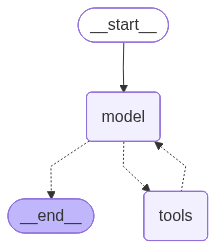

In [8]:
from datetime import datetime

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from prompts import SIMPLE_RESEARCH_INSTRUCTIONS, SUBAGENT_USAGE_INSTRUCTIONS
from tools import web_search

# 동시 연구 작업 단위 최대 개수 제한 설정
max_concurrent_research_units = 3
# 연구자 에이전트 반복 횟수 최대값 설정
max_researcher_iterations = 3

# 연구용 Sub-agent 구성 정보 딕셔너리 생성
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}

# 모델 초기화
model = ChatOpenAI(
    model_name="gpt-4.1",
    temperature=0.0,
)

# Sub-agent에 할당할 도구 리스트
sub_agent_tools = [web_search]

# Sub-agent에게 작업 위임을 위한 task 도구 생성
task_tool = create_task_tool(
    sub_agent_tools, [research_sub_agent], model, SubAgentDeepAgentState
)

# Supervisor Agent가 사용할 도구 리스트
delegation_tools = [task_tool]

# Supervisor Agent 생성
agent = create_agent(
    model,
    delegation_tools,
    system_prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
        date=datetime.now().strftime("%a %b %-d, %Y"),
    ),
    state_schema=SubAgentDeepAgentState,
)
agent

In [9]:
import nest_asyncio

nest_asyncio.apply()

result = await agent.ainvoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "2025년 12월 기준, Claude의 Agent Skills 에 대해서 심층적인 리서치 후, 그 중에서도 Delegation 에 대해 깊이 있는 보고서로 만들어줘.",
            }
        ]
    }
)
result

{'messages': [HumanMessage(content='2025년 12월 기준, Claude의 Agent Skills 에 대해서 심층적인 리서치 후, 그 중에서도 Delegation 에 대해 깊이 있는 보고서로 만들어줘.', additional_kwargs={}, response_metadata={}, id='de818a8f-2ddf-424e-8b85-6ed0347a2966'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 715, 'total_tokens': 804, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_92419d3fe9', 'id': 'chatcmpl-Cng17ZMmY6owILVNEojFrJLbD4Fy9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b2b28-4de3-7f02-9741-a8797dcf219a-0', tool_calls=[{'name': 'task', 'args': {'description': '2025년 12월 기준, Claude의 Agent Skills에 대한 심층적인 리서치를 수행하라. Claude의 Agent Skills의